# camel beauty assessor — preprocessing

takes the merged dataset, splits it, and writes two yolo-ready copies: one rgb,
one grayscale.

resizing is deliberately not done here. yolo letterboxes at load time from the
full-resolution original, so the input size stays a config choice.

## 1. setup

### 1.1 imports

In [1]:
import os
import csv
import shutil
import random
import collections

import pandas as pd
import matplotlib.pyplot as plt
from PIL import Image, ImageChops, ImageEnhance
import imagehash

### 1.2 paths

In [2]:
src = "dataset/camel-merged-v1"
out_rgb = "dataset/camel-rgb"
out_gray = "dataset/camel-gray"

### 1.3 display options

In [3]:
plt.rcParams.update({"figure.dpi": 110, "axes.grid": True, "grid.alpha": 0.3})

pd.set_option("display.width", 250)
pd.set_option("display.max_columns", 60)
pd.set_option("display.max_rows", 300)
pd.set_option("display.max_colwidth", 60)
pd.set_option("display.expand_frame_repr", False)

### 1.4 config

In [4]:
seed = 42
ratios = {"train": 0.70, "val": 0.15, "test": 0.15}

canon = ["Camel", "High_withers", "Large-head", "Large-lips", "Large-nose",
         "Large_hump", "Long-legs", "Long-neck", "Wide_body"]
traits = [c for c in canon if c != "Camel"]

assert abs(sum(ratios.values()) - 1) < 1e-9

## 2. helpers

In [5]:
def read_manifest(folder):
    with open(os.path.join(folder, "manifest.csv"), encoding="utf-8") as fh:
        return list(csv.DictReader(fh))


def label_path(folder, image_name):
    return os.path.join(folder, "labels", os.path.splitext(image_name)[0] + ".txt")


def read_label(folder, image_name):
    with open(label_path(folder, image_name), encoding="utf-8") as fh:
        return [l.split() for l in fh if l.strip()]


def classes_in(folder, image_name):
    return [canon[int(p[0])] for p in read_label(folder, image_name)]

## 3. input check

preprocessing assumes the merged dataset is already clean. duplicates are handled
upstream in the eda notebook, so this section only reports. it changes nothing.
a warning here means the wrong folder was exported.

In [6]:
mf = pd.DataFrame(read_manifest(src))
images = sorted(os.listdir(os.path.join(src, "images")))

print(f"images in folder     {len(images)}")
print(f"rows in manifest     {len(mf)}")
print(f"manifest matches     {sorted(mf.new_name) == images}")

missing = [i for i in images if not os.path.exists(label_path(src, i))]
print(f"images with no label {len(missing)}")

lines = sum(len(read_label(src, i)) for i in images)
print(f"annotation lines     {lines}")
print()
print(mf.bucket.value_counts().sort_index().to_string())

images in folder     196
rows in manifest     196
manifest matches     True
images with no label 0
annotation lines     1065

bucket
BEAUTY_A      77
BEAUTY_B      21
NEGATIVE_A    78
NEGATIVE_B    20


In [7]:
hashes = {i: imagehash.phash(Image.open(os.path.join(src, "images", i)).convert("RGB"))
          for i in images}

near = []
keys = list(hashes)
for a in range(len(keys)):
    for b in range(a + 1, len(keys)):
        d = hashes[keys[a]] - hashes[keys[b]]
        if d <= 8:
            near.append((d, keys[a], keys[b]))

if near:
    print(f"WARNING: {len(near)} near-duplicate pairs still present")
    print("resolve these in the eda notebook and re-export before training")
    for d, a, b in sorted(near)[:10]:
        print(f"   d={d}  {a}  <->  {b}")
else:
    print("no near-duplicates found, input is clean")

resolve these in the eda notebook and re-export before training
   d=0  BEAUTY_B020.png  <->  NEGATIVE_B004.png
   d=0  NEGATIVE_B017.png  <->  NEGATIVE_B019.png
   d=2  BEAUTY_A059.jpeg  <->  BEAUTY_A073.jpeg
   d=4  BEAUTY_A034.jpeg  <->  BEAUTY_A051.jpeg
   d=4  NEGATIVE_B013.png  <->  NEGATIVE_B017.png
   d=4  NEGATIVE_B013.png  <->  NEGATIVE_B019.png
   d=6  BEAUTY_B012.jpeg  <->  BEAUTY_B019.jpeg
   d=6  BEAUTY_B020.png  <->  NEGATIVE_B012.png
   d=6  BEAUTY_B021.png  <->  NEGATIVE_B012.png
   d=6  NEGATIVE_A030.jpeg  <->  NEGATIVE_A031.jpeg


## 4. split

stratified on `group`, so pretty and ugly keep their proportions in every split.
the two source batches are one dataset after the merge and are not split on.

In [8]:
random.seed(seed)

groups = collections.defaultdict(list)
for r in read_manifest(src):
    groups[r["group"]].append(r["new_name"])

split_of = {}
for group, names in sorted(groups.items()):
    names = sorted(names)
    random.shuffle(names)
    n_train = round(len(names) * ratios["train"])
    n_val = round(len(names) * ratios["val"])
    for i, name in enumerate(names):
        if i < n_train:
            split_of[name] = "train"
        elif i < n_train + n_val:
            split_of[name] = "val"
        else:
            split_of[name] = "test"

split_df = pd.DataFrame([{"image": k, "split": v} for k, v in sorted(split_of.items())])
split_df["group"] = split_df.image.str.extract(r"^(BEAUTY|NEGATIVE)")

pd.crosstab(split_df.group, split_df.split).reindex(columns=["train", "val", "test"])

split,train,val,test
group,,,
BEAUTY,69,15,14
NEGATIVE,69,15,14


the batch tag survives in the filenames as provenance, so where each batch landed
is worth a look even though it was not split on. a heavy skew here would be worth
knowing about, since the two batches annotate ugly camels differently.

In [9]:
split_df["batch"] = split_df.image.str.extract(r"^[A-Z]+_([AB])")
pd.crosstab(split_df.batch, split_df.split).reindex(columns=["train", "val", "test"])

split,train,val,test
batch,,,
A,115,19,21
B,23,11,7


In [10]:
rows = []
for name, sp in split_of.items():
    for c in classes_in(src, name):
        rows.append({"split": sp, "cls": c})

per_class = (pd.DataFrame(rows).groupby(["cls", "split"]).size()
             .unstack(fill_value=0)
             .reindex(index=canon, columns=["train", "val", "test"], fill_value=0))
per_class["total"] = per_class.sum(axis=1)
per_class

split,train,val,test,total
cls,,,,
Camel,226,50,38,314
High_withers,65,13,11,89
Large-head,34,19,10,63
Large-lips,66,15,14,95
Large-nose,59,14,13,86
Large_hump,60,13,11,84
Long-legs,70,14,16,100
Long-neck,98,20,23,141
Wide_body,65,16,12,93


In [11]:
thin = per_class[(per_class.test < 5) | (per_class.val < 5)]
if len(thin):
    print("classes with fewer than 5 boxes in val or test:")
    print(thin[["train", "val", "test"]].to_string())
    print()
    print("metrics on these will be noisy - a single missed box moves recall a lot.")
    print("worth considering k-fold cross validation instead of one fixed split.")
else:
    print("every class has at least 5 boxes in val and test")

every class has at least 5 boxes in val and test


## 5. export

two datasets, identical splits and identical labels. the only difference is
colour, which makes them a clean a/b pair for the two required experiments.

In [12]:
def export(dst, grayscale):
    shutil.rmtree(dst, ignore_errors=True)
    for sp in ratios:
        os.makedirs(os.path.join(dst, sp, "images"))
        os.makedirs(os.path.join(dst, sp, "labels"))

    for name, sp in sorted(split_of.items()):
        img = Image.open(os.path.join(src, "images", name))
        if grayscale:
            # back to 3 channels: yolo expects rgb input even when it is all grey
            img = img.convert("L").convert("RGB")
        else:
            img = img.convert("RGB")
        img.save(os.path.join(dst, sp, "images", name))
        shutil.copy2(label_path(src, name),
                     os.path.join(dst, sp, "labels", os.path.splitext(name)[0] + ".txt"))

    with open(os.path.join(dst, "data.yaml"), "w", encoding="utf-8") as fh:
        fh.write("path: .\ntrain: train/images\nval: val/images\ntest: test/images\n\n")
        fh.write(f"nc: {len(canon)}\n")
        fh.write("names: [" + ", ".join(f"'{c}'" for c in canon) + "]\n")
    return dst


export(out_rgb, grayscale=False)
export(out_gray, grayscale=True)

for d in (out_rgb, out_gray):
    counts = {sp: len(os.listdir(os.path.join(d, sp, "images"))) for sp in ratios}
    print(f"{d:<22} {counts}   total {sum(counts.values())}")

dataset/camel-rgb      {'train': 138, 'val': 30, 'test': 28}   total 196
dataset/camel-gray     {'train': 138, 'val': 30, 'test': 28}   total 196


## 6. verification

the export is only trustworthy if the split is airtight and the two copies differ
in nothing but colour.

In [13]:
def collect(dst):
    out = {}
    for sp in ratios:
        for f in os.listdir(os.path.join(dst, sp, "images")):
            out.setdefault(f, []).append(sp)
    return out


checks = {}

placed = collect(out_rgb)
checks["every image placed exactly once"] = all(len(v) == 1 for v in placed.values())
checks["no image lost"] = len(placed) == len(images)

rgb_files = collect(out_rgb)
gray_files = collect(out_gray)
checks["rgb and gray have the same split"] = rgb_files == gray_files

same_labels = True
total_lines = 0
for sp in ratios:
    for f in os.listdir(os.path.join(out_rgb, sp, "labels")):
        a = open(os.path.join(out_rgb, sp, "labels", f), encoding="utf-8").read()
        b = open(os.path.join(out_gray, sp, "labels", f), encoding="utf-8").read()
        c = open(os.path.join(src, "labels", f), encoding="utf-8").read()
        total_lines += len([l for l in a.splitlines() if l.strip()])
        if not (a == b == c):
            same_labels = False
checks["labels identical to source"] = same_labels
checks["annotation lines preserved"] = total_lines == lines

for k, v in checks.items():
    print(f"  {'PASS' if v else 'FAIL'}  {k}")
assert all(checks.values()), "a verification check failed"

  PASS  every image placed exactly once
  PASS  no image lost
  PASS  rgb and gray have the same split
  PASS  labels identical to source
  PASS  annotation lines preserved


In [14]:
def is_grayscale(path):
    r, g, b = Image.open(path).convert("RGB").split()
    return (ImageChops.difference(r, g).getbbox() is None
            and ImageChops.difference(g, b).getbbox() is None)


sample_rgb = os.path.join(out_rgb, "train", "images", sorted(os.listdir(os.path.join(out_rgb, "train", "images")))[0])
sample_gray = sample_rgb.replace(out_rgb, out_gray)

print(f"rgb copy  is grayscale: {is_grayscale(sample_rgb)}   (expected False)")
print(f"gray copy is grayscale: {is_grayscale(sample_gray)}   (expected True)")
print()
print(f"disk: rgb {sum(os.path.getsize(os.path.join(dp, f)) for dp, _, fs in os.walk(out_rgb) for f in fs) / 1e6:.0f} mb")
print(f"      gray {sum(os.path.getsize(os.path.join(dp, f)) for dp, _, fs in os.walk(out_gray) for f in fs) / 1e6:.0f} mb")

rgb copy  is grayscale: False   (expected False)
gray copy is grayscale: True   (expected True)

disk: rgb 63 mb
      gray 37 mb


## 7. augmentation

ultralytics is the library that trains yolo. it loads the images, augments them,
runs the training loop and reports the metrics. augmentation happens as each
image is loaded, so every epoch sees a different variation of the same 138
training images. the dataset does not grow on disk, and an augmented image
cannot reach val or test.

nothing is augmented here on purpose. the settings belong with the training run.

## 8. what got built

In [15]:
summary = []
for d, label in ((out_rgb, "rgb"), (out_gray, "grayscale")):
    for sp in ["train", "val", "test"]:
        n_img = len(os.listdir(os.path.join(d, sp, "images")))
        n_box = sum(len(open(os.path.join(d, sp, "labels", f), encoding="utf-8").readlines())
                    for f in os.listdir(os.path.join(d, sp, "labels")))
        summary.append({"dataset": label, "split": sp, "images": n_img, "annotations": n_box})

pd.DataFrame(summary).pivot(index="split", columns="dataset", values=["images", "annotations"]).reindex(["train", "val", "test"])

images      annotations     
dataset grayscale  rgb   grayscale  rgb
split                                  
train         138  138         743  743
val            30   30         174  174
test           28   28         148  148

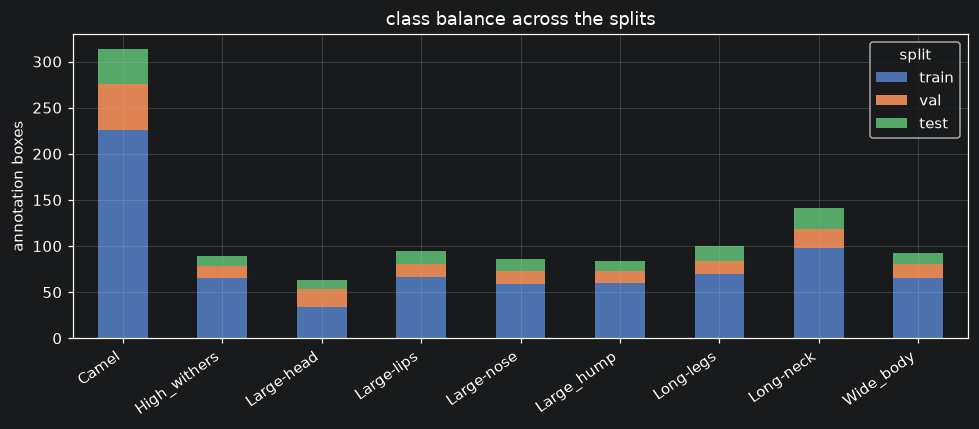

In [16]:
fig, ax = plt.subplots(figsize=(9, 4))
per_class[["train", "val", "test"]].plot(kind="bar", stacked=True, ax=ax,
                                         color=["#4c72b0", "#dd8452", "#55a868"])
ax.set_ylabel("annotation boxes")
ax.set_xlabel("")
ax.set_title("class balance across the splits")
plt.xticks(rotation=35, ha="right")
plt.tight_layout()
plt.show()